In [118]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

In [119]:
df = pd.read_csv("movies_10y_metadata_with_counts_both.csv")
df.head()

,image_path,title,popularity,release_date,image_height,image_width,person_count_L,person_count_UL
0,filtered_posters/poster_0.jpg,57 Seconds,1036.051,2023-09-29,750,500,2,3
1,filtered_posters/poster_1.jpg,Mission: Impossible - Dead Reckoning Part One,3132.329,2023-07-08,750,500,7,15
2,filtered_posters/poster_2.jpg,Expend4bles,1063.874,2023-09-15,750,500,7,13
3,filtered_posters/poster_3.jpg,Sound of Freedom,1271.779,2023-07-03,750,500,1,3
4,filtered_posters/poster_4.jpg,Nowhere,1290.251,2023-09-29,750,500,1,1


In [120]:
df_model = df[[
    "popularity",
    "person_count_L",
    "person_count_UL"
]].copy()

df_model["person_count"] = df_model["person_count_L"]

In [121]:
X = df_model[["person_count"]]
y = df_model["popularity"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42)

In [122]:
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

In [123]:
y_pred = gb.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print("Gradient Boosting MSE:", mse)

rmse = np.sqrt(mse)
print("Gradient Boosting RMSE:", rmse)

Gradient Boosting MSE: 4524.5964981271245
Gradient Boosting RMSE: 67.26512096270343


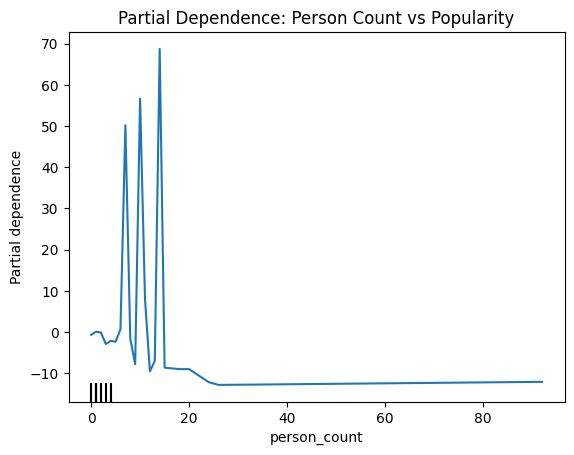

In [124]:
PartialDependenceDisplay.from_estimator(
    gb,
    X_train,
    features=["person_count"])

plt.title("Partial Dependence: Person Count vs Popularity")
plt.show()